# 10.3.2 极点配置与输入代价

## 学习目标与先修知识

在可控模型（model）中配置极点（pole），核对反馈（feedback）符号与执行需求。

先修：10.3.1能控矩阵（matrix）、10.2.1特征根以及第8篇二次代价。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

可控以后，能否把反馈调得“无限快”？数学上的极点配置只保证理想线性模型的特征根，不自动保证执行器能提供所需幅度。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

在双积分模型上先展开 $\det[sI-(A-BK)]$，对目标极点−1、−2手算两个系数。

In [2]:
p1,p2=-1.,-2.;print("目标多项式 s² + k2 s + k1 的系数：",-(p1+p2),p1*p2)

目标多项式 s² + k2 s + k1 的系数： 3.0 2.0


## 模型假设

连续双积分对象 $A=[[0,1],[0,0]]$、$B=[0,1]^\mathsf T$；完整状态（state）x可用，反馈符号固定为u=−Kx。先在无约束模型中配置实负极点，再另加 $|u|\le3$ 的执行上限。极点配置推导不包含饱和和测量噪声（measurement noise）。

## 数学解释与推导

令 $K=[k_1,k_2]$，则
$$A-BK=\begin{bmatrix}0&1\\-k_1&-k_2\end{bmatrix},\qquad \det[sI-(A-BK)]=s^2+k_2s+k_1.$$
目标极点p₁、p₂对应 $(s-p_1)(s-p_2)=s^2-(p_1+p_2)s+p_1p_2$，因此 $k_1=p_1p_2$、$k_2=-(p_1+p_2)$。目标−1、−2给K=[2,3]。这一步之所以能任意指定两个根，依赖10.3.1已确认的满秩（rank）能控性（controllability）。

拓展提示：满秩能控性支持任意极点配置，比仅要求闭环稳定更强。若不可控模态（mode）的连续时间特征值（eigenvalue）实部均为负，系统仍可能具有可稳定性（stabilizability）；本节不展开一般判据。

若把两个目标根的绝对值增大十倍，k₁增大一百倍，初态给定时请求输入（input）也会显著增加。实际执行 $\operatorname{clip}(-Kx,-u_{max},u_{max})$ 后，闭环不再是原矩阵A−BK；应以裁剪后的输入更新并验证性能。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def canonical_feedback(pole1, pole2):
    """A=[[0,1],[0,0]], B=[0,1], u=-Kx."""
    return [pole1 * pole2, -(pole1 + pole2)]

## 对照实验

比较温和和快速目标极点的理想轨迹（trajectory）与限幅轨迹，同时画实际执行输入。初始化相同，隔离反馈增益（gain）和限幅造成的差异。

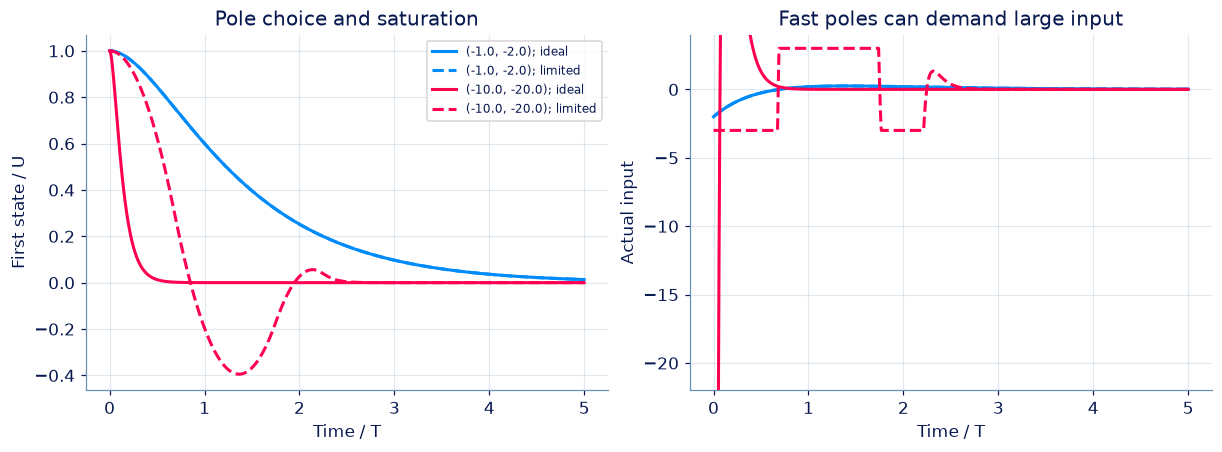

In [4]:
initial=np.array([1.,0.]);h=.001;steps=5000
fig,axes=plt.subplots(1,2,figsize=(11,4))
for poles,color in [((-1.,-2.),BLUE),((-10.,-20.),PINK)]:
    K=np.array(canonical_feedback(*poles))
    for cap,style in [(None,'-'),(3.,'--')]:
        x=initial.copy();states=[];actions=[]
        for _ in range(steps):
            request=-float(K@x);u=request if cap is None else float(np.clip(request,-cap,cap))
            states.append(x[0]);actions.append(u)
            x=x+h*np.array([x[1],u])
        label=f'{poles}; '+('ideal' if cap is None else 'limited')
        axes[0].plot(np.arange(steps)*h,states,color=color,ls=style,label=label)
        axes[1].plot(np.arange(steps)*h,actions,color=color,ls=style,label=label)
axes[0].set(xlabel='Time / T',ylabel='First state / U',title='Pole choice and saturation');axes[0].legend(fontsize=8)
axes[1].set(xlabel='Time / T',ylabel='Actual input',title='Fast poles can demand large input');axes[1].set_ylim(-22,4);plt.show()

## 结果解释

快速极点在理想模型下缩短暂态（transient），却可能要求远超3的初始输入。限幅轨迹并非这些目标极点所代表的线性闭环，因此它与理想轨迹不同。选择极点时应同时审查输入、测量、模型和约束。

### 独立核对

用独立的矩阵特征值（eigenvalue）程序核对反馈符号和两个目标根，并核对限幅输入从未超过3。

In [5]:
A=np.array([[0.,1.],[0.,0.]]);B=np.array([[0.],[1.]])
for poles in [(-1.,-2.),(-10.,-20.)]:
    K=np.array(canonical_feedback(*poles)).reshape(1,2)
    np.testing.assert_allclose(sorted(np.linalg.eigvals(A-B@K)),sorted(poles),atol=1e-12)
assert abs(np.clip(-float(np.array(canonical_feedback(-10.,-20.))@initial),-3,3))<=3
print('A−BK的极点与目标一致，执行上限需独立处理。')

A−BK的极点与目标一致，执行上限需独立处理。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：配置双积分反馈极点

连续双积分模型（model） A=[[0,1],[0,0]]、B=[0,1]ᵀ，采用 u=−Kx。输入（input）两个实的负目标极点（pole），返回 K=[k1,k2]。

**函数与代码模板**

```python
def solve(
    pole1: float,
    pole2: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `pole1` | `float` | 第一个目标极点。 | 1/T |
| `pole2` | `float` | 第二个目标极点。 | 1/T |

**返回值**

直接返回 gain（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gain` | `list[float]` | 反馈（feedback）行向量（vector）[k1,k2]，使A−BK的特征根为目标值。 | 随状态定义 |

**计算规则**

det(sI−(A−BK))=s²+k2s+k1=(s−p1)(s−p2)，故k1=p1p2，k2=−(p1+p2)。

**约束与边界**

- 输入均为有限数；只需实现题定模型，不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| pole1 | 第一个目标极点。 | -1 | 1/T |
| pole2 | 第二个目标极点。 | -2 | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
pole1 = -1.0
pole2 = -2.0

result = solve(pole1, pole2)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gain | 反馈（feedback）行向量（vector）[k1,k2]，使A−BK的特征根为目标值。 | [2.0, 3.0] | 随状态定义 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 3.0]
```

**样例解释**

目标−1、−2给K=[2,3]；将其代入A−BK应恢复s²+3s+2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：配置双积分反馈极点](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-canonical-gain)

### 第 2 题 · 单项选择题：反馈符号统一

教材约定 u=−Kx。设计增益（gain）后应检查哪个闭环矩阵（matrix）？

- **A.** A−BK。
- **B.** A+BK。
- **C.** A−KC。
- **D.** A⁻¹BK。

[作答：反馈符号统一](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-feedback-sign)

### 第 3 题 · 多项选择题：极点越快越好吗

同一个双积分对象上把目标极点（pole）从−1、−2改为−10、−20。哪些结果可能随之改变？

- **A.** 反馈（feedback）增益（gain）和初始输入（input）需求会显著增大。
- **B.** 线性理想模型（model）的暂态（transient）会更快。
- **C.** 执行饱和和测量误差可使实际表现偏离理想极点结论。
- **D.** 极点变快自动消除所有输入代价。

[作答：极点越快越好吗](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-fast-pole-cost)

### 第 4 题 · 单项选择题：不可控时不能任意配置

若 [B,AB] 秩（rank）只有1，给出任意两个目标极点（pole）时，以下何者正确？

- **A.** 无法保证两个模态（mode）都按目标配置。
- **B.** 只要K的数字够大就一定可配置。
- **C.** 不可控模态可由输入（input）直接移动。
- **D.** 这证明对象没有任何可稳定的方向。

[作答：不可控时不能任意配置](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-pole-placement-condition)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。